# Cosmic Intelligence Lab

## Deep Galaxy Explorer — Study 001

# Notebook 006 — Build First Astronomical Catalog

---

## Research Question

How can we convert detected astronomical sources into a structured catalog suitable for scientific analysis and AI?

---

## Objectives

- Create a SourceCatalog from the segmentation map
- Measure properties of detected objects
- Explore source positions, brightness, and sizes
- Convert measurements into an Astropy Table
- Save the catalog for later notebooks

In [1]:
# Cell 2 - Import Required Libraries ===========================

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits

from photutils.background import Background2D, MedianBackground
from photutils.segmentation import detect_sources
from photutils.segmentation import SourceCatalog

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Cell 3 - Load Hubble FITS Image ==============================

fits_file = Path("../data/raw/mastDownload/HST/ib5x1fetq/ib5x1fetq_flt.fits")

with fits.open(fits_file) as hdul:
    science = hdul["SCI"].data

print("Science image loaded.")

print("Shape :", science.shape)
print("Data type :", science.dtype)

Science image loaded.
Shape : (1014, 1014)
Data type : >f4


In [3]:
# Cell 4 - Estimate Background ================================

bkg = Background2D(
    science,
    box_size=(50, 50),
    filter_size=(3, 3),
    bkg_estimator=MedianBackground()
)

science_sub = science - bkg.background

print("Background estimated.")

print(f"Mean background : {bkg.background.mean():.3f}")
print(f"Background RMS  : {bkg.background_rms_median:.3f}")

Background estimated.
Mean background : 0.467
Background RMS  : 0.023


In [4]:
# Cell 5 - Detect Astronomical Sources =========================

sigma = 3
min_pixels = 5

threshold = bkg.background + sigma * bkg.background_rms

segment_map = detect_sources(
    science_sub,
    threshold,
    n_pixels=min_pixels
)

print(f"Detected sources : {segment_map.n_labels}")

Detected sources : 95


In [5]:
# Cell 6 - Build the Source Catalog ============================

catalog = SourceCatalog(
    science_sub,
    segment_map
)

print("Source catalog created successfully.")
print(f"Number of catalog entries : {len(catalog)}")

Source catalog created successfully.
Number of catalog entries : 95


In [6]:
# Cell 7 - Convert Catalog to Table ============================

table = catalog.to_table()

print(f"Columns available: {len(table.colnames)}")
print()

table.colnames

Columns available: 19



['label',
 'x_centroid',
 'y_centroid',
 'sky_centroid',
 'bbox_xmin',
 'bbox_xmax',
 'bbox_ymin',
 'bbox_ymax',
 'area',
 'semimajor_axis',
 'semiminor_axis',
 'orientation',
 'eccentricity',
 'min_value',
 'max_value',
 'segment_flux',
 'segment_flux_err',
 'kron_flux',
 'kron_flux_err']

In [7]:
# Cell 8 - Display Selected Source Properties ==================

columns = [
    "label",
    "x_centroid",
    "y_centroid",
    "segment_flux",
    "area"
]

table[columns][:10]

label,x_centroid,y_centroid,segment_flux,area
,,,,pix2
int32,float64,float64,float64,float64
1,1011.1558648801878,1.9725426798241823,103.97923684120178,24.0
2,736.7927696461153,11.42845451172875,19.497517228126526,16.0
3,622.1228461046784,18.82930759190662,31.58135676383972,16.0
4,121.18956760830898,31.32029442469728,6.465743601322174,6.0
5,529.4126604123757,79.48980618510005,24.018874406814575,32.0
6,540.0202264635453,79.18836128348309,12.340121269226074,15.0
7,809.1891942549092,84.74331593280078,11.399610340595245,13.0
8,620.784680169983,90.4208343944767,6.043212354183197,10.0


In [8]:
# Cell 9 - Save Catalog ========================================

catalog_file = Path("../data/catalogs/source_catalog.ecsv")

table.write(
    catalog_file,
    format="ascii.ecsv",
    overwrite=True
)

print(f"Catalog saved to:\n{catalog_file}")

Catalog saved to:
../data/catalogs/source_catalog.ecsv


In [9]:
# Cell 10 - Verify Catalog =====================================

from astropy.table import Table

catalog_check = Table.read(
    catalog_file,
    format="ascii.ecsv"
)

print(f"Rows    : {len(catalog_check)}")
print(f"Columns : {len(catalog_check.colnames)}")

catalog_check[:5]

Rows    : 95
Columns : 19


label,x_centroid,y_centroid,sky_centroid,bbox_xmin,bbox_xmax,bbox_ymin,bbox_ymax,area,semimajor_axis,semiminor_axis,orientation,eccentricity,min_value,max_value,segment_flux,segment_flux_err,kron_flux,kron_flux_err
,,,,,,,,pix2,pix,pix,deg,,,,,,,
int32,float64,float64,object,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,1011.1558648801878,1.9725426798241823,None,1007,1013,0,6,24.0,2.1532985095548427,1.4546436878746936,59.68625869106634,0.7373214628932244,1.7645800113677979,8.897390365600586,103.97923684120178,nan,97.36517517204038,nan
2,736.7927696461153,11.42845451172875,None,735,739,10,13,16.0,1.0425375485147124,0.8473819282730207,30.763603254853948,0.5825329240047639,0.6191791296005249,2.931279420852661,19.497517228126526,nan,27.61112048642445,nan
3,622.1228461046784,18.82930759190662,None,621,624,17,21,16.0,0.8541513400365031,0.7580456582502352,277.7009772993434,0.4608385055033623,0.5621078014373779,12.082280158996582,31.58135676383972,nan,34.42159785873663,nan
4,121.18956760830898,31.32029442469728,None,120,122,30,32,6.0,0.6440643877584695,0.5514238892637224,294.4995327788689,0.516706370668758,0.5479127168655396,2.140134334564209,6.465743601322174,nan,12.983454270407863,nan
5,529.4126604123757,79.48980618510005,None,525,532,76,84,32.0,2.2941649471403283,1.4005674373639603,303.90657994640236,0.7920230641969821,0.5414181351661682,1.639194130897522,24.018874406814575,nan,95.29540050691291,nan


In [10]:
# Cell 11 - Brightest Detected Sources =========================

brightest = table.copy()

brightest.sort("segment_flux")

brightest.reverse()

brightest[
    "label",
    "segment_flux",
    "area",
    "x_centroid",
    "y_centroid"
][:10]

label,segment_flux,area,x_centroid,y_centroid
,,pix2,,
int32,float64,float64,float64,float64
89,6329.181792199612,549.0,468.5523186090346,1010.746479456142
85,4832.935794949532,360.0,8.851709529799736,1005.5918960462978
61,1051.520471215248,104.0,251.64304436683952,688.0455845203842
88,972.4510651230812,136.0,1007.7163210264586,1007.2057328616334
51,482.0046505331993,200.0,279.1875567053194,565.3944376201048
53,301.5857663154602,133.0,14.559708388963733,583.9146713483202
22,247.06091219186783,40.0,781.5620346158696,199.6624715383293
91,245.16374111175537,43.0,412.1973568957496,1010.821692895649


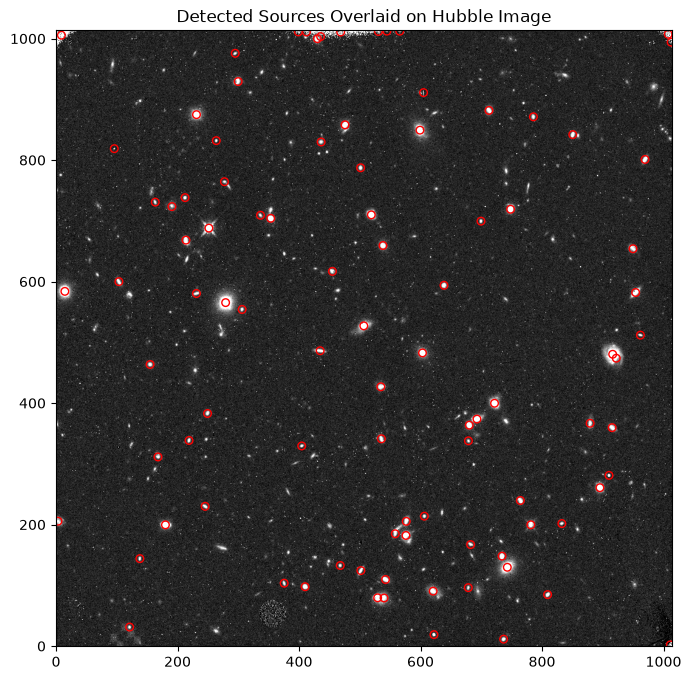

In [13]:
# Cell 12 - Overlay Catalog on Image ===========================

plt.figure(figsize=(8,8))

vmin, vmax = np.percentile(science_sub, (1, 99.3))

plt.imshow(
    science_sub,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

plt.scatter(
    table["x_centroid"],
    table["y_centroid"],
    s=30,
    facecolors="none",
    edgecolors="red",
    linewidths=1
)

plt.title("Detected Sources Overlaid on Hubble Image")

plt.show()

In [14]:
# Cell 13 - Notebook Status ==================================

from datetime import datetime

print("=" * 60)
print("Notebook Status")
print("=" * 60)

print("Status    : PASS")
print("Notebook  : 06_build_first_astronomical_catalog.ipynb")
print("Completed :", datetime.now().strftime("%Y-%m-%d %H:%M"))

Notebook Status
Status    : PASS
Notebook  : 06_build_first_astronomical_catalog.ipynb
Completed : 2026-07-14 09:40
